## Guía 1

https://www.kaggle.com/datasets/luisfelipetn/valor-casas-usadas-chile-rm-08032023

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

## Exploratory Data Analysis

In [84]:
data = pd.read_csv("../datasets/2023-03-08 Precios Casas RM.csv") #Importar dataset
#data

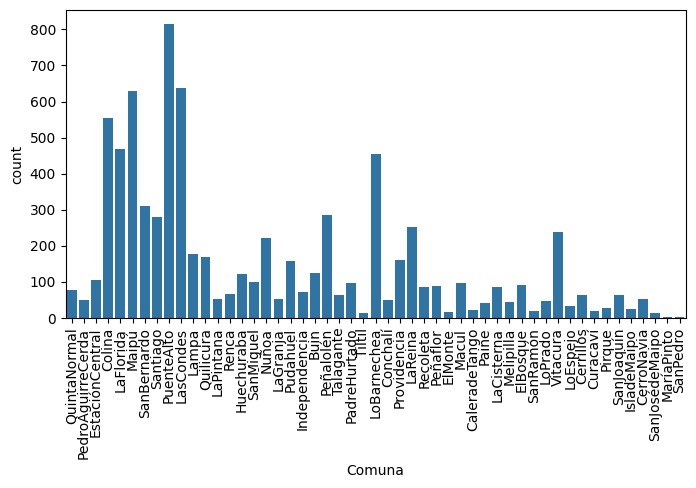

In [85]:
#Plot comunas
plt.figure(figsize=(8,4))
sns.countplot(data, x ="Comuna")
plt.xticks(rotation=90)
plt.show()

In [86]:
data.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='object')

In [87]:
data

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades
...,...,...,...,...,...,...,...,...,...,...,...,...
7774,2491300000,70000,3102491,LasCondes,CalleSanJosédeLaSierra,5,5.0,600.0,1800.0,5.0,4708915,Propiedades Viña Limitada ®
7775,242012000,6800,301385,Peñalolén,PasajeMarNegro,4,2.0,124.0,200.0,1.0,6641660,NaN
7776,3736950000,105000,4653736,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7.0,460.0,4925.0,8.0,6032811,Tsi Property
7777,569440000,16000,709141,LaPintana,LosCipreses/LosDuraznos,4,2.0,311.0,2011.0,1.0,5314376,Tsi Property


In [88]:
data = data.drop(columns = ["Comuna", "Ubicacion", "Realtor", "id", "Price_USD", "Price_CLP"])

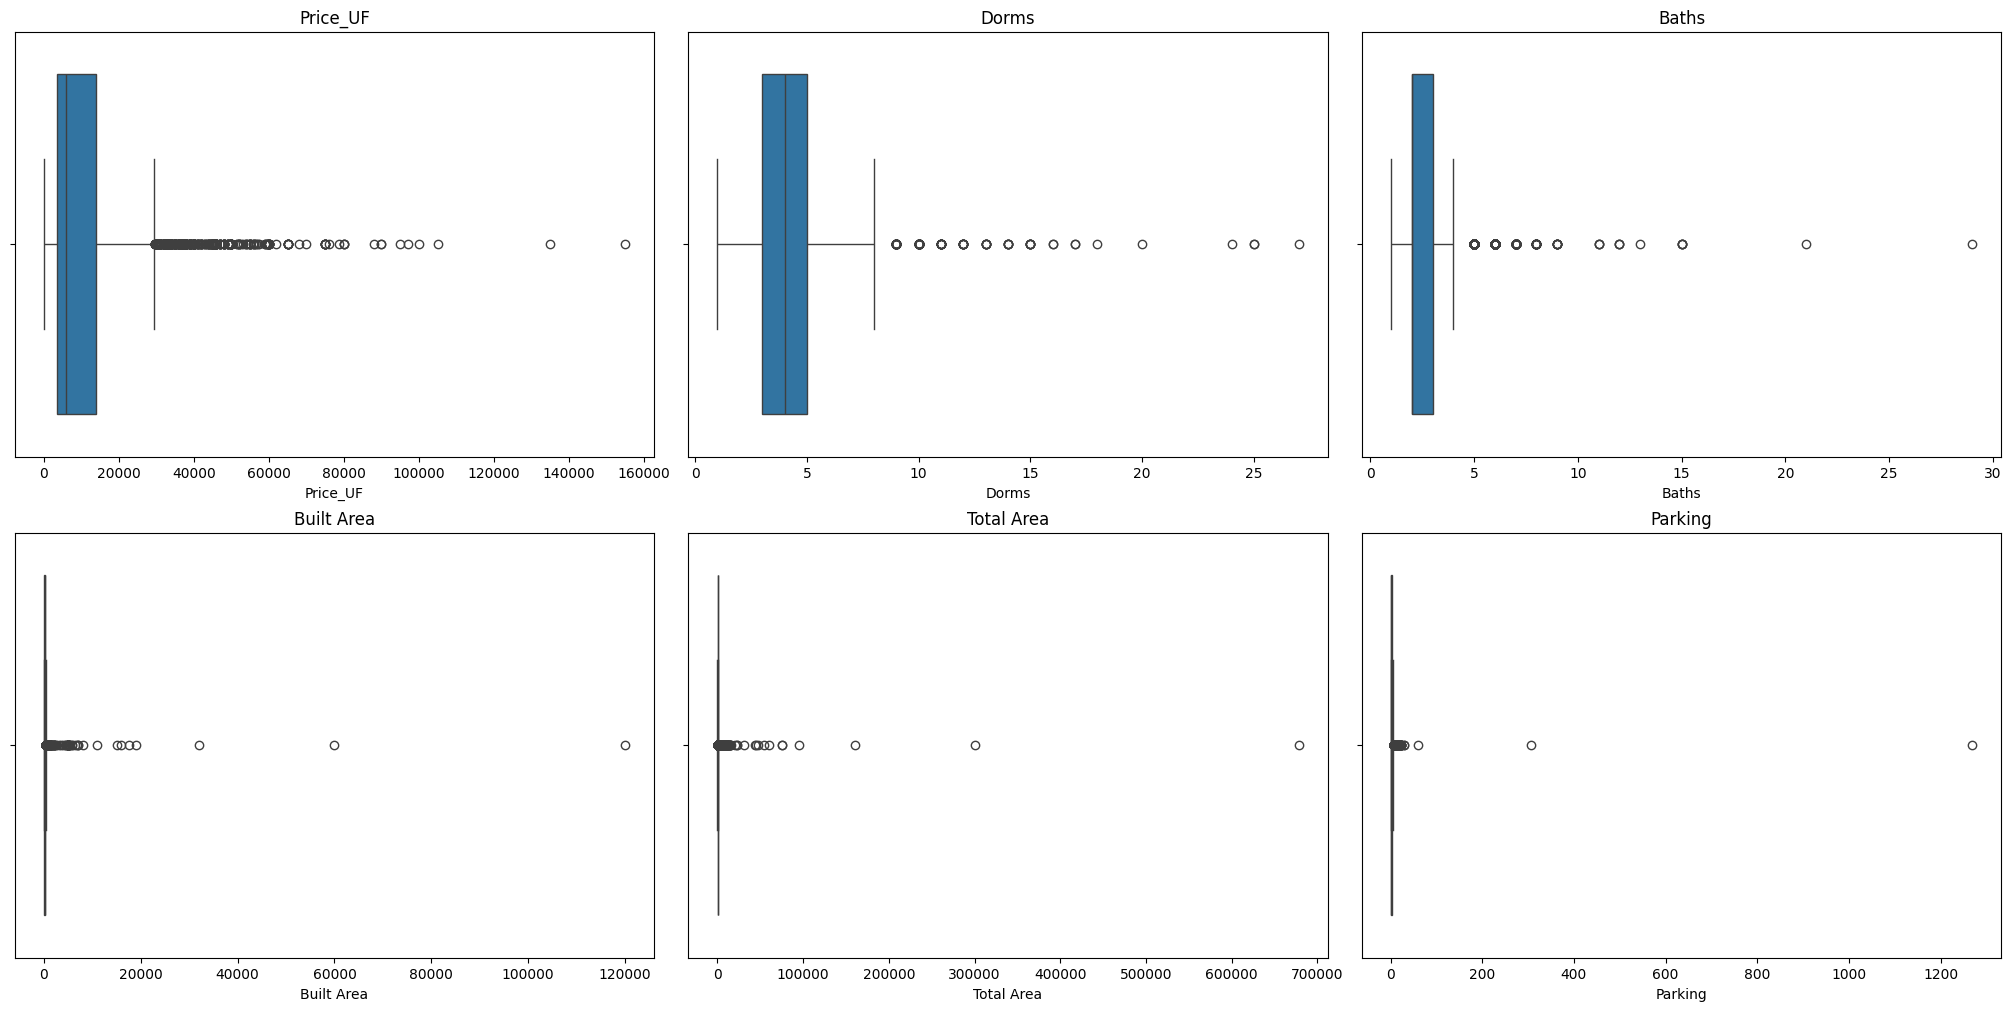

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.columns):
    sns.boxplot(data, x = column, ax=axes[index//3, index%3])
    axes[index//3, index%3].set_title(column)
plt.show()

In [90]:
data.describe()

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
count,7779.000000,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000
mean,10234.571153,3.994087,2.653746,229.923669,807.919826,2.980506
std,10870.491584,1.622821,1.465103,1676.898812,9050.893115,17.749384
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3372.000000,3.000000,2.000000,85.000000,129.500000,1.000000
50%,5760.000000,4.000000,2.000000,128.000000,210.000000,2.000000
75%,13800.000000,5.000000,3.000000,200.000000,443.000000,3.000000
max,155000.000000,27.000000,29.000000,120000.000000,678000.000000,1269.000000


In [91]:
#Filter data
def iqr(data, column): #Inter quantile range
    q3 = data[column].quantile(0.75) #3er cuartil
    q1 = data[column].quantile(0.25) #1er cuartil
    superior_limit = q3 + 1.5*(q3 - q1)
    inferior_limit = q1 - 1.5*(q3 - q1)
    return data[(data[column] < superior_limit) & (data[column] > inferior_limit)] #Selects data

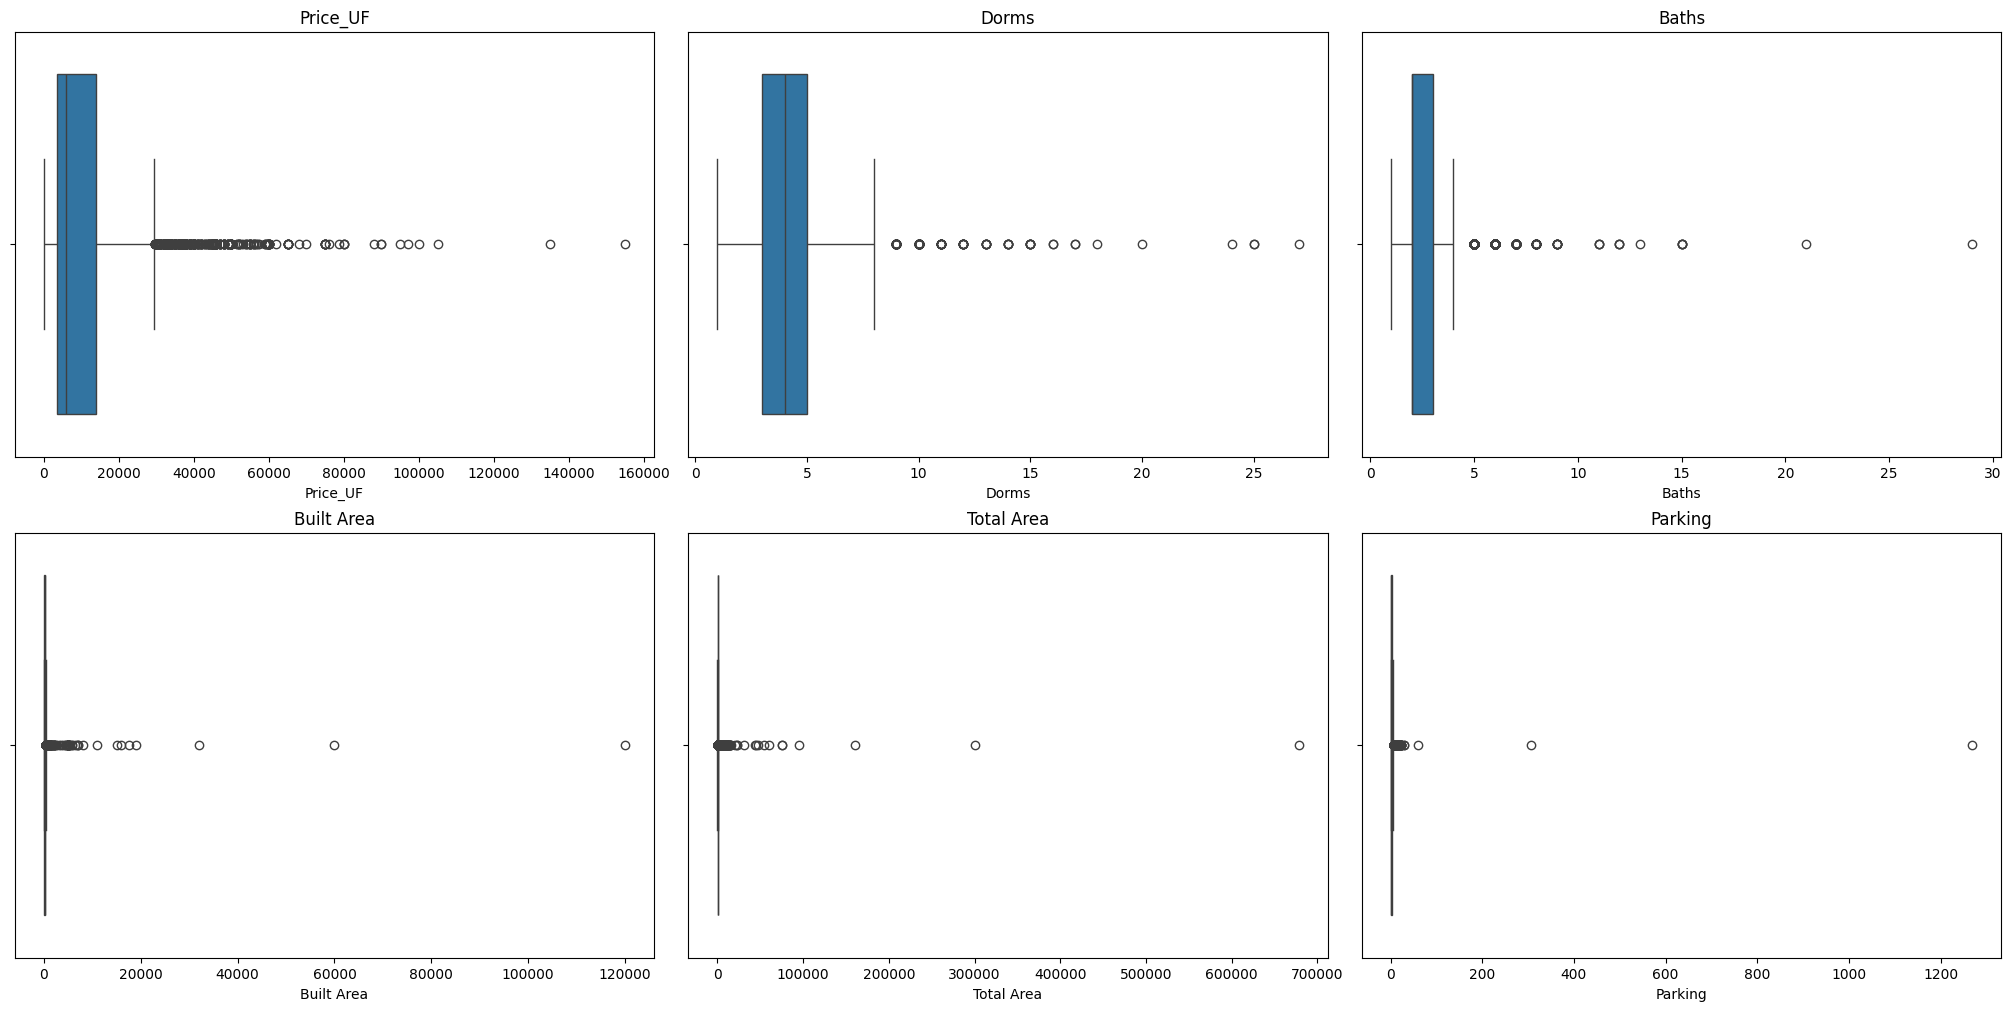

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
for index, column in enumerate(data.columns):
    sns.boxplot(data, x = column, ax=axes[index//3, index%3])
    axes[index//3, index%3].set_title(column)
plt.show()

In [93]:
for col in ['Dorms', 'Baths', 'Built Area', 'Total Area', 'Parking']: #Iteration
    data = iqr(data, col) #Uses IQR

In [94]:
for column in data.columns: #Iterar las columnas
    data = data[data[column].notna()] #Borrar nulos
    print(column, len(data[data[column].isna()])) #Ver la cantidad de nulos

Price_UF 0
Dorms 0
Baths 0
Built Area 0
Total Area 0
Parking 0


In [95]:
data #Display

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
1,2950,2,1.0,112.0,145.0,1.0
2,3600,3,1.0,59.0,243.0,2.0
3,2107,3,1.0,103.0,73.0,1.0
4,1489,2,1.0,57.0,67.0,1.0
6,2107,3,1.0,70.0,80.0,2.0
...,...,...,...,...,...,...
7767,0,3,3.0,100.0,199.0,2.0
7768,5300,4,2.0,114.0,220.0,3.0
7769,1264,3,2.0,40.0,50.0,1.0
7772,2390,5,1.0,120.0,76.0,1.0


In [96]:
X = data[["Dorms", "Baths", "Built Area", "Total Area", "Parking"]] #Select this columns
y = data["Price_UF"]

## Model training

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42) #Dividir en entrenamiento y testing
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2766, 5), (922, 5), (2766,), (922,))

In [98]:
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures()),
        ("model", ElasticNet())
    ]
)

params = {
    "poly__degree": [1, 2, 3],
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
grid_search = GridSearchCV(pipeline, params, cv=5)
grid_search.fit(X_train, y_train)
display(grid_search.best_params_)
display(grid_search.best_score_)
pipeline = grid_search.best_estimator_

c:\Users\Gabriel\anaconda3\envs\ml_course\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.064e+07, tolerance: 7.145e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\Gabriel\anaconda3\envs\ml_course\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.054e+07, tolerance: 6.957e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\Gabriel\anaconda3\envs\ml_course\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

{'model__alpha': 0.1, 'model__l1_ratio': 0.9, 'poly__degree': 2}

np.float64(0.5653936330731842)

## Metrics

In [107]:
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r = np.sqrt(r2)
print("mse", mse)
print("rmse", rmse)
print("r2", r2)
print("r", r)

mse 7634777.26052905
rmse 2763.1100702883787
r2 0.6838491228282735
r 0.8269517052574917


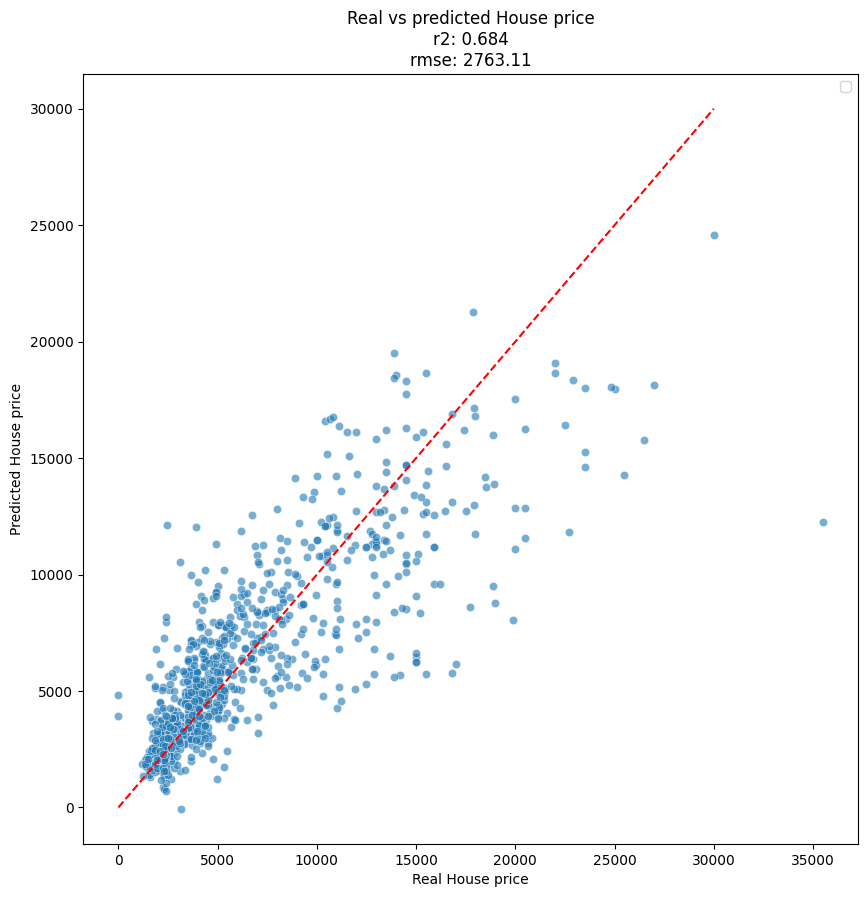

In [106]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.scatterplot(x = y_test, y = y_pred, alpha=0.6)
ax.set_xlabel("Real House price")
ax.set_ylabel("Predicted House price")
ax.set_title(f"Real vs predicted House price\nr2: {round(r2, 3)}\nrmse: {round(rmse, 3)}")
ax.plot([0, 30_000], [0, 30_000], "--", color="red")
ax.legend([])
plt.show()

In [101]:
coefs = pd.DataFrame(pipeline.named_steps["model"].sparse_coef_.toarray()).T
coefs = coefs.rename(columns={0: "coef"})
coefs["feature_names"] = pipeline.named_steps["poly"].get_feature_names_out(
    input_features = X_train.columns)

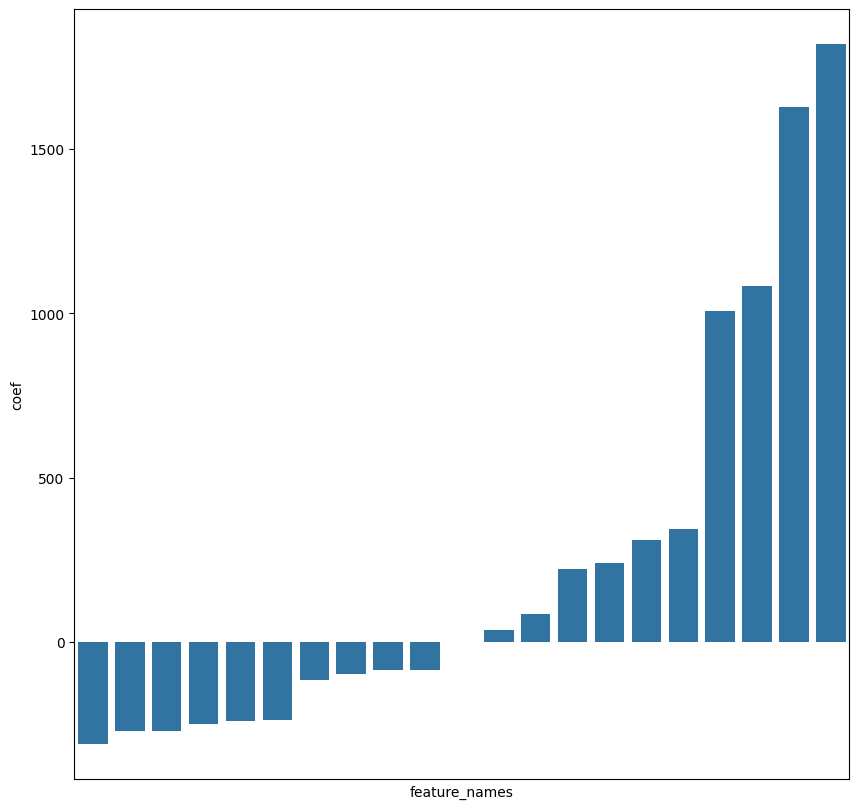

In [102]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(coefs.sort_values(by="coef"), x = "feature_names", y = "coef", axes=ax)
ax.set_xticks([])
plt.show()

In [103]:
coefs["abs_coef"] = coefs.coef.abs()
most_important = coefs.sort_values(by="abs_coef", ascending=False)[:20]

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_9372\3555459872.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(most_important.feature_names, rotation=90)


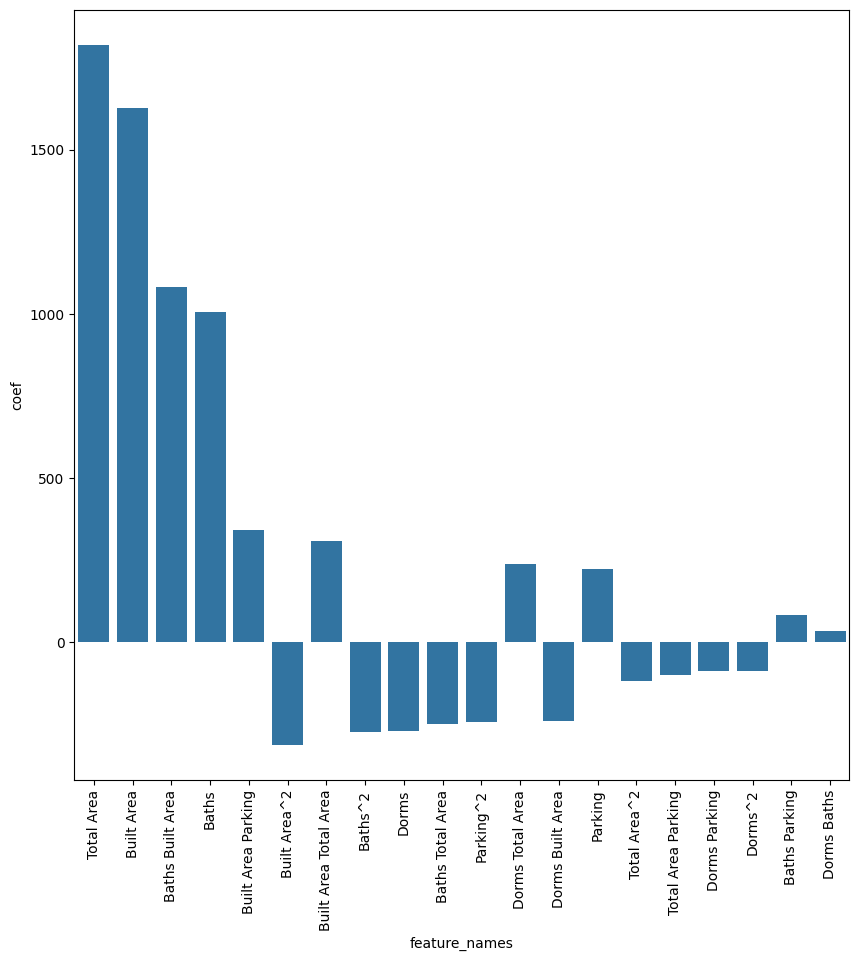

In [104]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(most_important, x = "feature_names", y = "coef", axes=ax)
ax.set_xticklabels(most_important.feature_names, rotation=90)
plt.show()